In [2]:
## notebook to analyze a frequency sweep electrically driving the plate to measure the
## transfer function versus frequency 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys, importlib, os, pyvisa
sys.path.append("labjack")
sys.path.append("..")
from functiongenerator import AFG2225
import labjack_utils as lu
from ReadPressure import read_pressure
import datetime, time
import scipy.signal as sp
sys.path.append("../../nanospheres/DAQ/InstekPPX10005")
import instekPPX10005 as ppx
# import msvcrt # for windows, key press detection--only if .py file is run

In [2]:
## data acquisition parameters:
sampling_rate = 1000 #Hz
num_samples = 2**14 #16 s per file
num_traces_per_file = 1 ## number of waveforms to save per file
num_files = 2 # number of files

### Synthesizer to drive electrodes
set_synth = True
synth_channel = 1 ## must be 1 or 2
noise_playback_freq = 28.6 ##0.086 #Hz
synth_amplitude = 2 #Vpp
electrodes_synth_address = "ASRL3::INSTR"

save_data = True
output_dir = 'C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/'
today= datetime.datetime.now().strftime('%Y%m%d')
output_path= os.path.join(output_dir, today) + "/"
# output_path = "C:/Users/yalen/Yale University Dropbox/David Moore/shared_drives/Microspheres/data/th228_sail/202504021/"

plot_data = True
plot_PSD = True

### do correlation with drive for charge measurement
plot_drive_correlation = True
f0 = 30 ## Hz, estimate of resonance frequency used for estimating phase shift in correlation
num_corr_samples = int(0.5 * sampling_rate/f0) ## number of samples in a half period 
channel_to_correlate = 'Y' ## channel to correlate with drive signal

### Synthesizer to flash LED with fxn generator
flash_LED = True
led_channel = 1 ## must be 1 or 2
led_amplitude = 7 #Vpp, positive voltage needed for LED; don't go over 7Vpp
led_width = 0.5 #s
led_synth_address = "ASRL8::INSTR"

## Settings for filament power supply
set_filament = True
filament_voltage = 2.2 #V
filament_time_on = 1.5 #s
max_filament_current = 2.5 #A
filament_supply_address = "ASRL9::INSTR"

save_pressure = True
pressure_port = "COM4"

if(not os.path.isdir(output_path)):
    os.makedirs(output_path)

In [3]:
#set noise on function generator if desired
if(set_synth):

    afg = AFG2225(electrodes_synth_address)
    afg.set_output_onoff(synth_channel, "OFF")
    afg.set_amplitude(synth_channel, synth_amplitude)
    afg.set_frequency(synth_channel, noise_playback_freq)
    afg.set_output_onoff(synth_channel, "ON")

if(flash_LED):

    led_afg = AFG2225(led_synth_address)
    led_afg.set_output_onoff(led_channel, "OFF")
    led_afg.set_amplitude(led_channel, led_amplitude)
    led_afg.set_offset(led_channel, led_amplitude/2) #set dc offset to avoid negative bias
    led_duty_cycle = 0.1 ## 10% works well
    led_freq_to_set = led_duty_cycle/led_width #want a given width after the duty cycle, Hz
    led_afg.set_wavetype(led_channel, "SQUARE")
    led_afg.set_frequency(led_channel, led_freq_to_set)
    led_afg.set_square_duty(led_channel, led_duty_cycle*100) #duty cycle in percent
    led_afg.set_burst(led_channel, state='ON', mode='TRIG', ncycles=1, trig_source='MAN')
    
    led_afg.set_output_onoff(synth_channel, "ON")

if(set_filament):
    fil_supply = ppx.open(filament_supply_address)
    ppx.set_voltage(fil_supply, filament_voltage, max_filament_current)


Instrument did not return anything when trying to read


In [58]:
ppx.set_output(fil_supply, 'on') #turn on filament
time.sleep(filament_time_on) #wait for filament to heat up
ppx.set_output(fil_supply, 'off') #turn off filament

In [17]:
led_afg.send_manual_trigger(led_channel)

In [4]:
importlib.reload(lu)

lj = lu.LabJack()

channels_to_read = [0,1,2,3]
ch_names = ['X', 'Y', 'Sum', 'Drive']
num_channels = len(channels_to_read)

## open labjack ad configure
#lj.open()
#lj.config(sample_rate=sampling_rate, num_samps_to_read=num_samples, channel_list=channels_to_read,)


=== File 0 | Phase = baseline ===
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


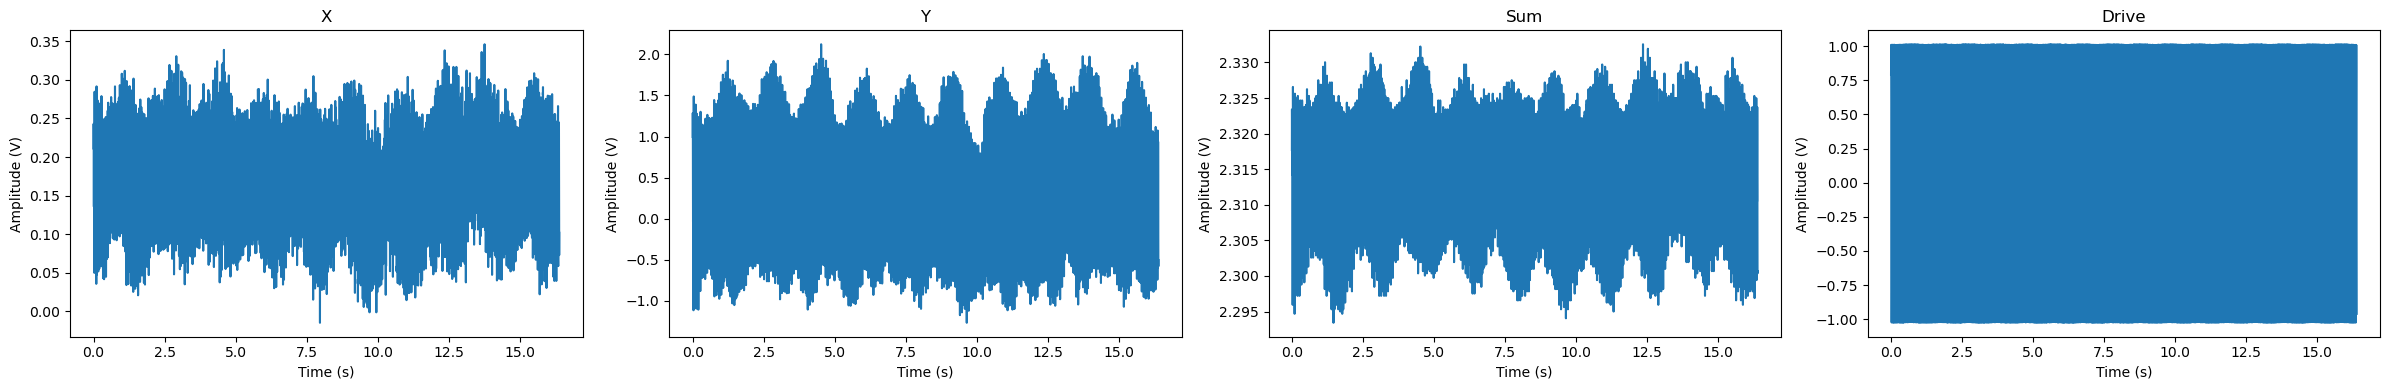

Drive frequency: 28.63 Hz
Peak amplitude: 0.49 V^2/Hz


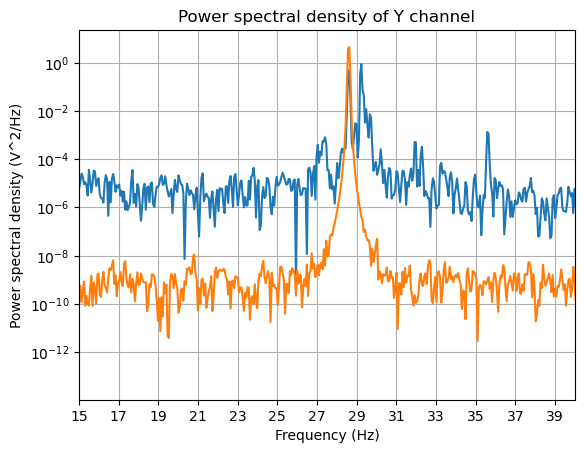

Max correlation: 2.68e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


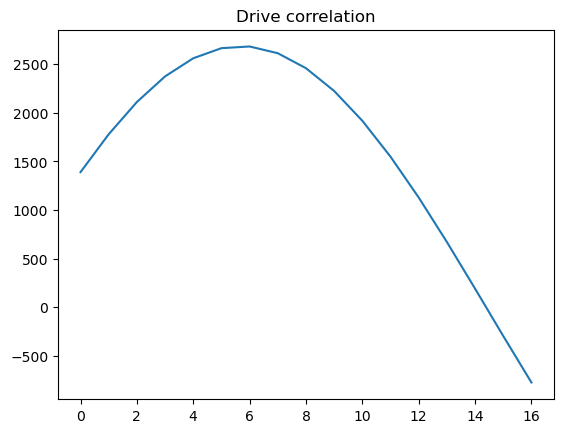


=== File 1 | Phase = baseline ===
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


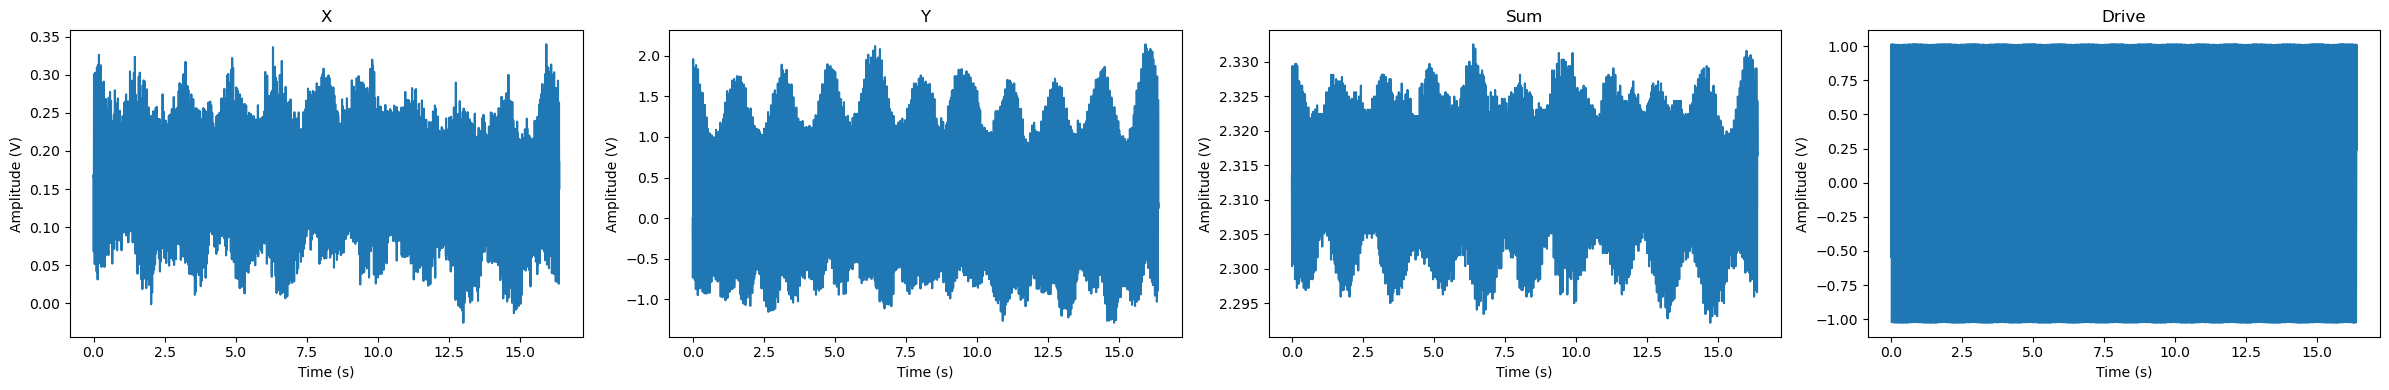

Drive frequency: 28.63 Hz
Peak amplitude: 0.49 V^2/Hz


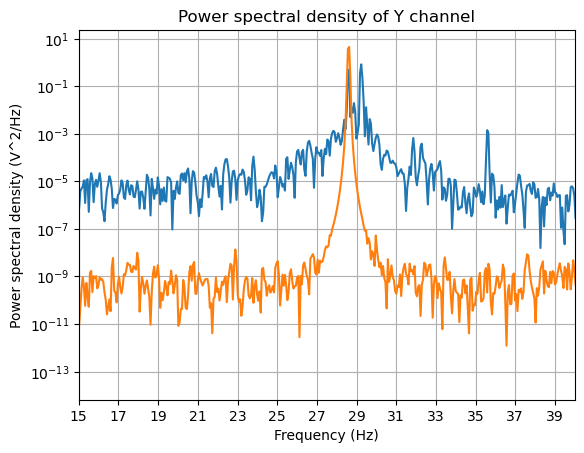

Max correlation: 3.12e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


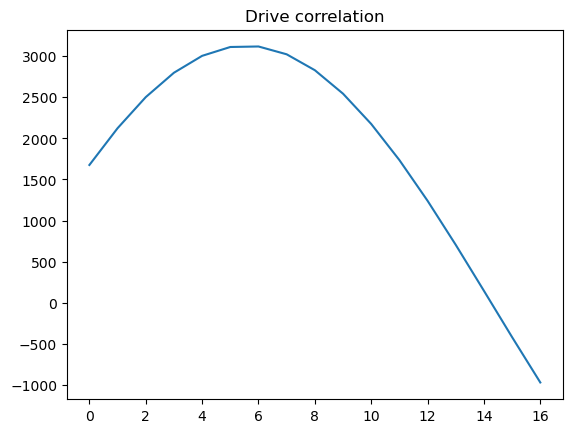


=== File 2 | Phase = baseline ===
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


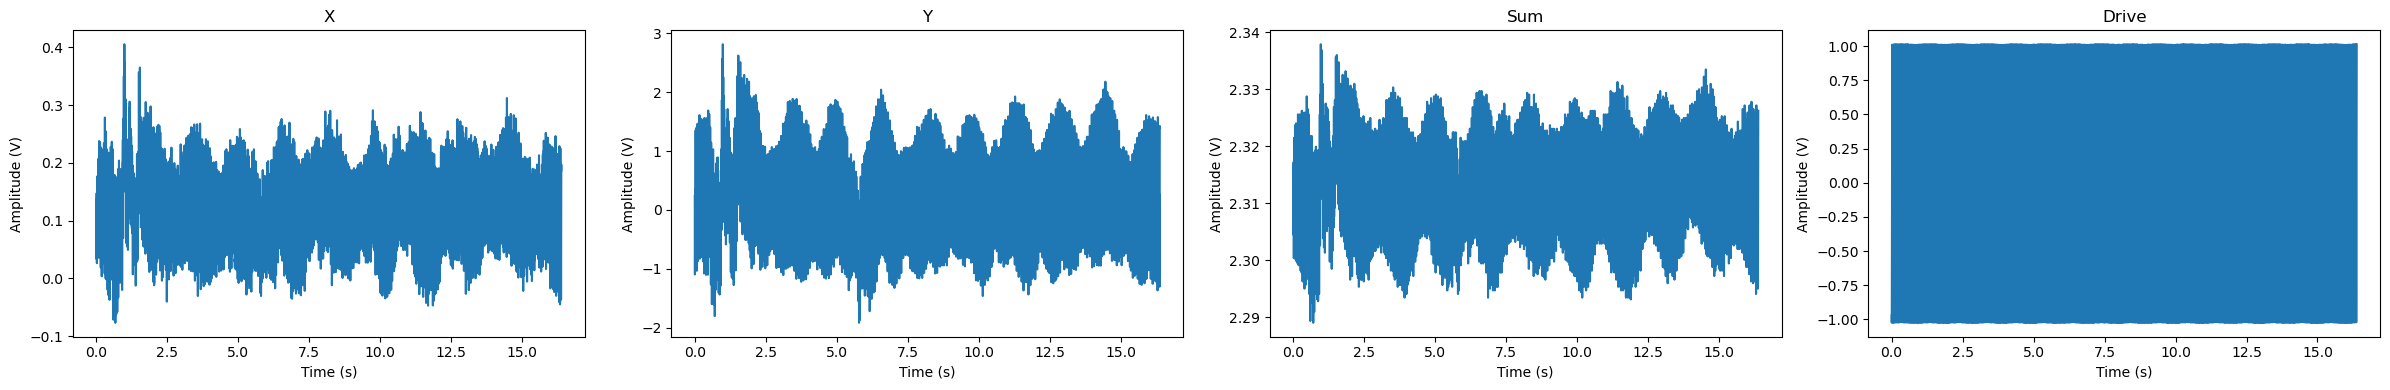

Drive frequency: 28.63 Hz
Peak amplitude: 0.76 V^2/Hz


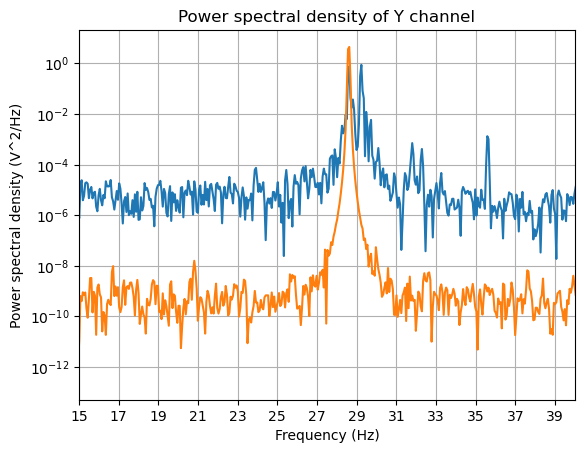

Max correlation: 3.55e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


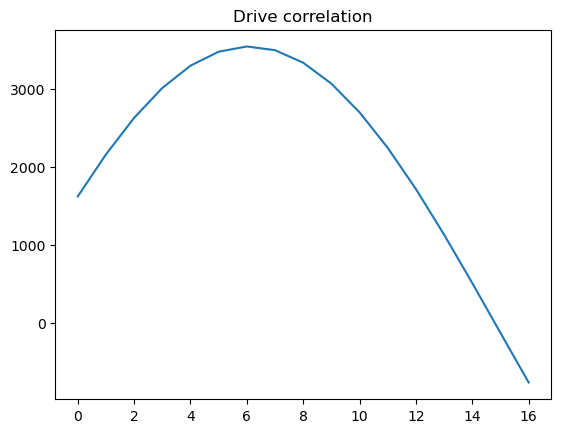


=== File 3 | Phase = baseline ===
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


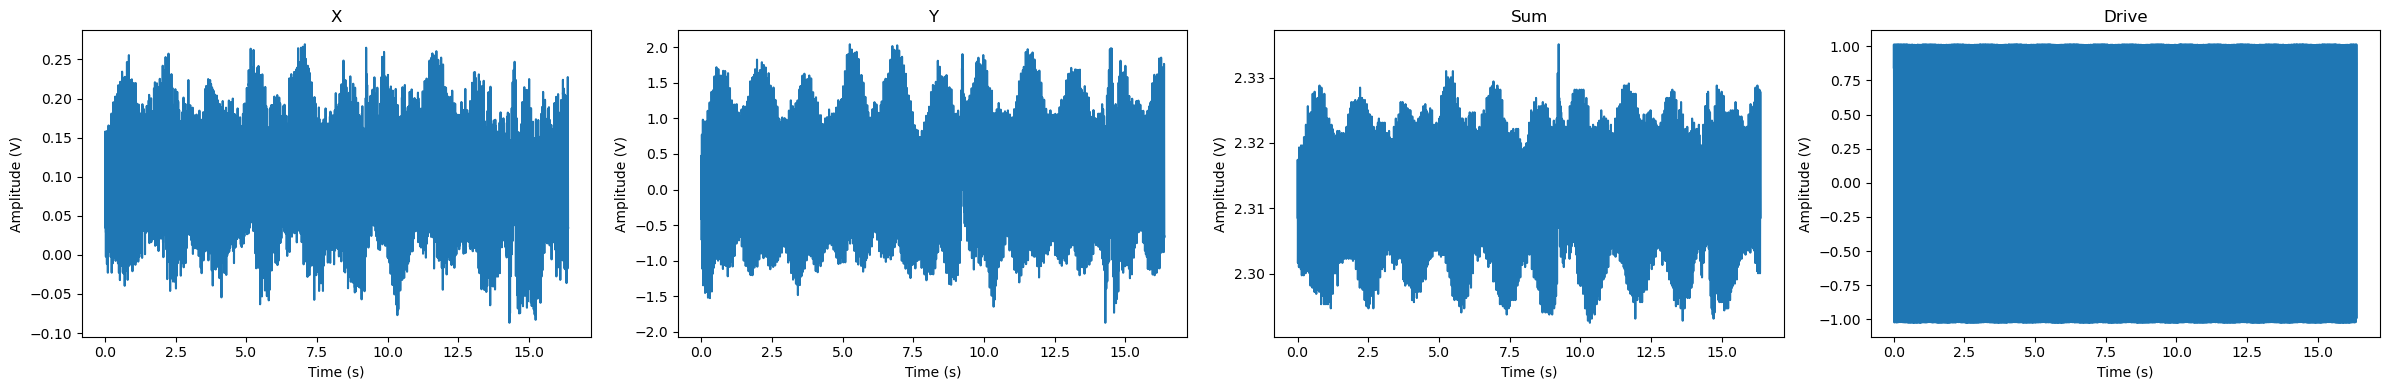

Drive frequency: 28.63 Hz
Peak amplitude: 0.83 V^2/Hz


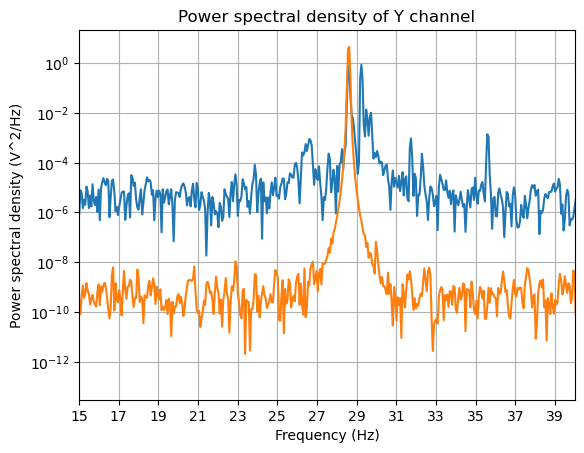

Max correlation: 3.64e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


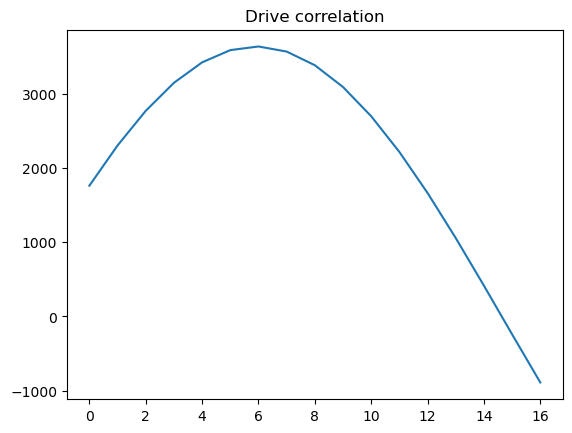


=== File 4 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


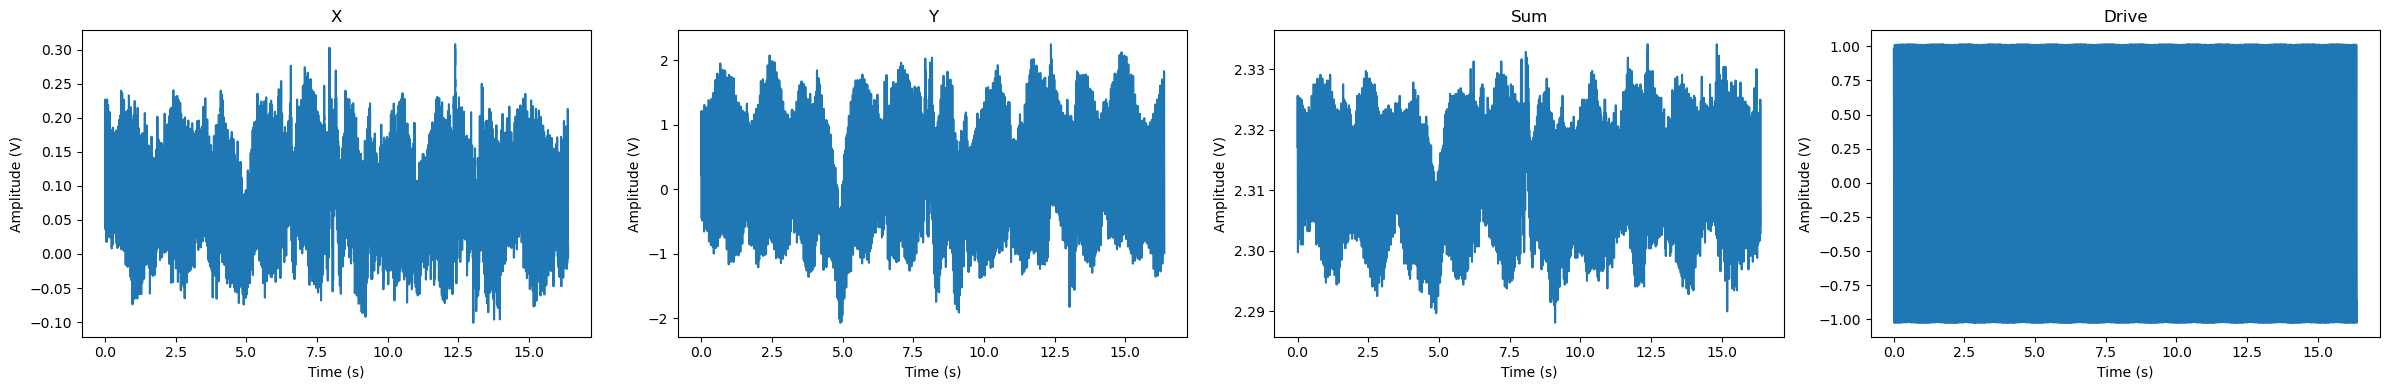

Drive frequency: 28.63 Hz
Peak amplitude: 0.89 V^2/Hz


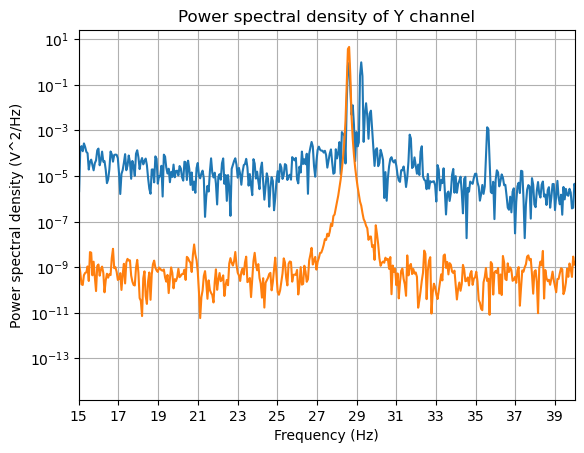

Max correlation: 3.71e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


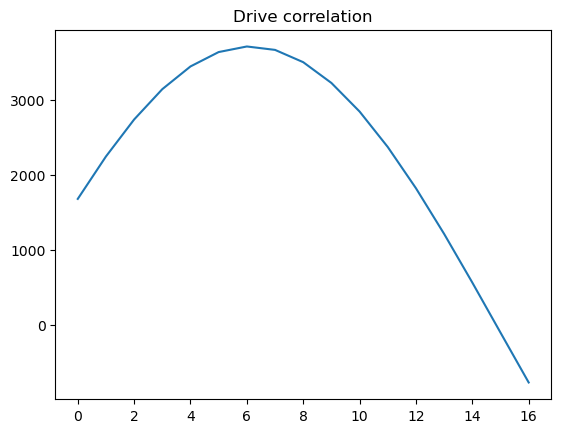


=== File 5 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


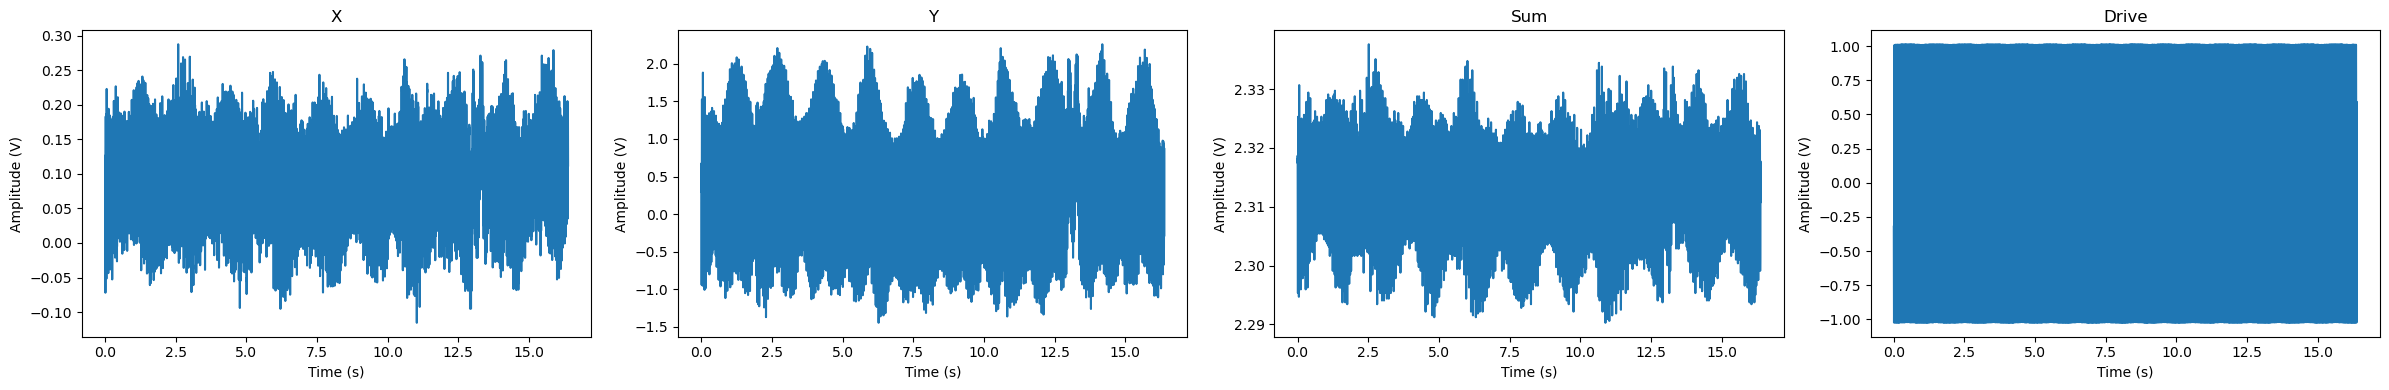

Drive frequency: 28.63 Hz
Peak amplitude: 1.02 V^2/Hz


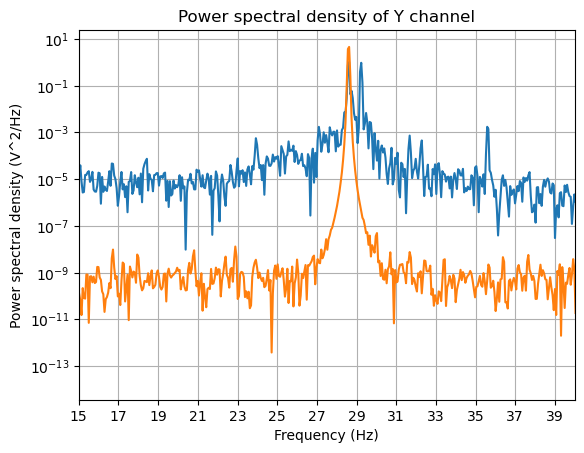

Max correlation: 3.91e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


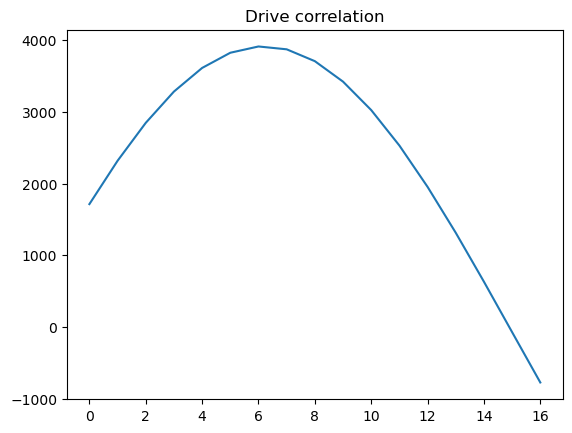


=== File 6 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


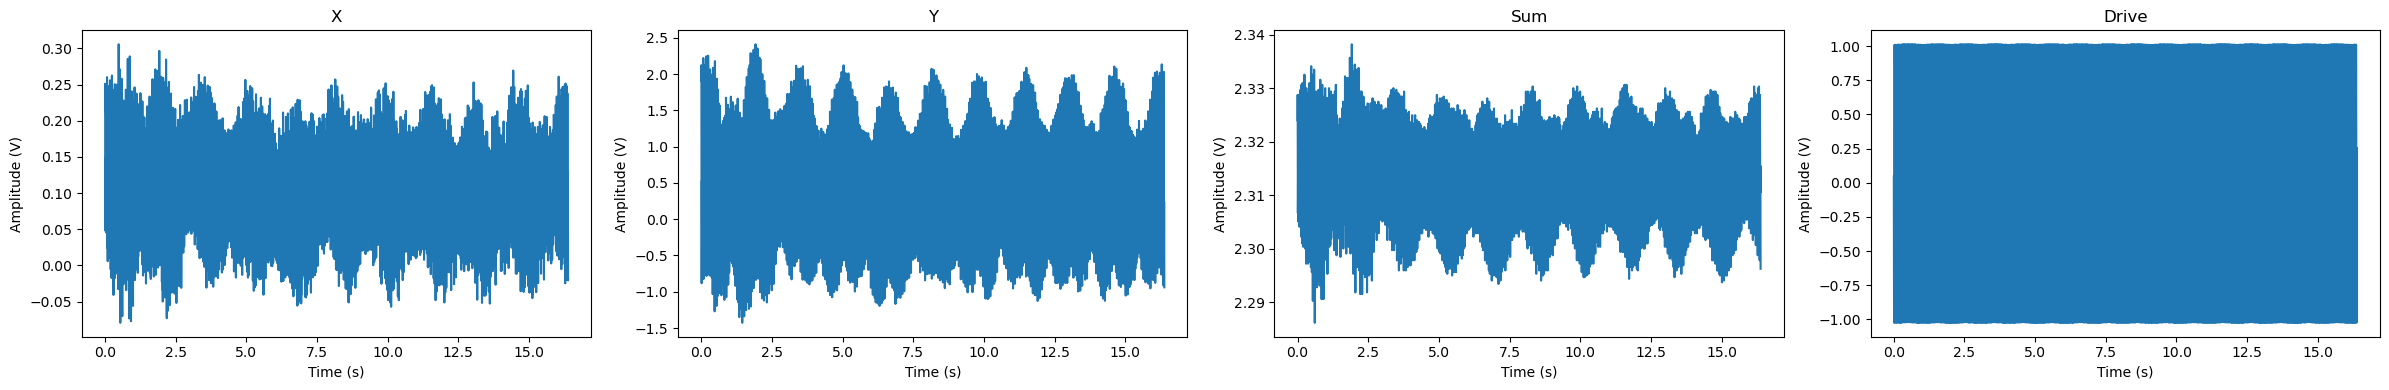

Drive frequency: 28.63 Hz
Peak amplitude: 0.85 V^2/Hz


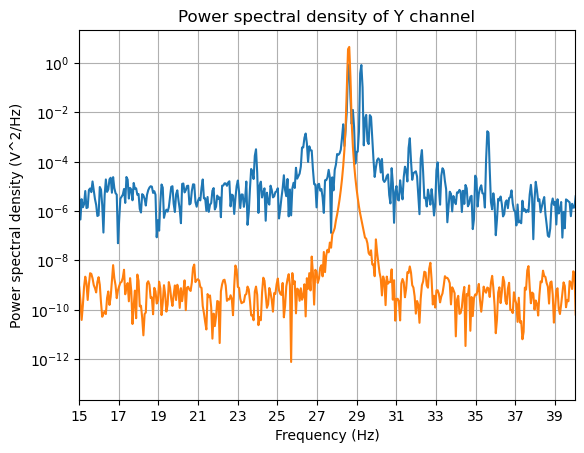

Max correlation: 4.18e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 0.94 rad
Phase shift: 54.00 deg


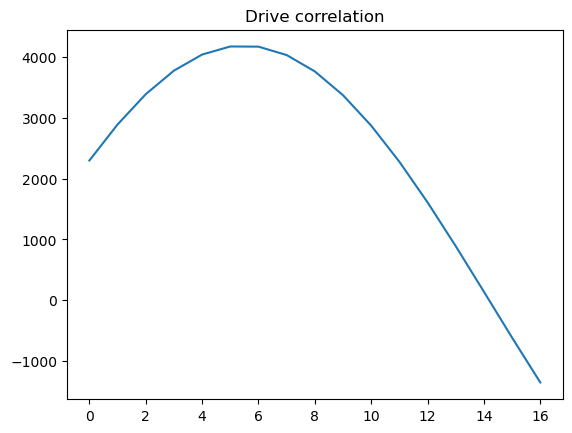


=== File 7 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


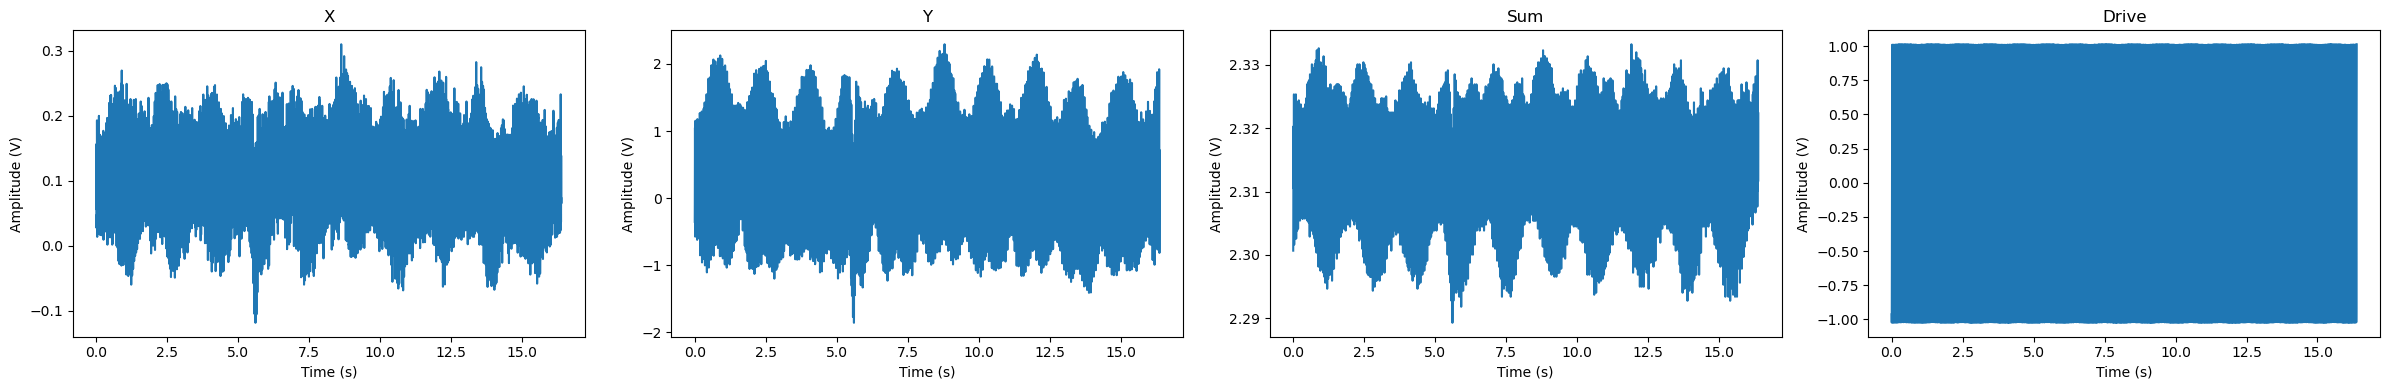

Drive frequency: 28.63 Hz
Peak amplitude: 1.16 V^2/Hz


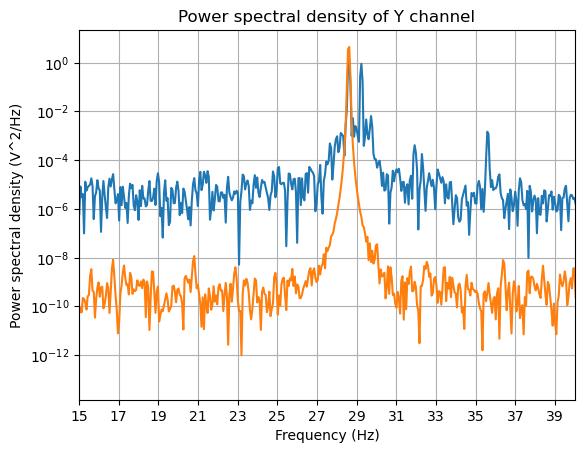

Max correlation: 4.03e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


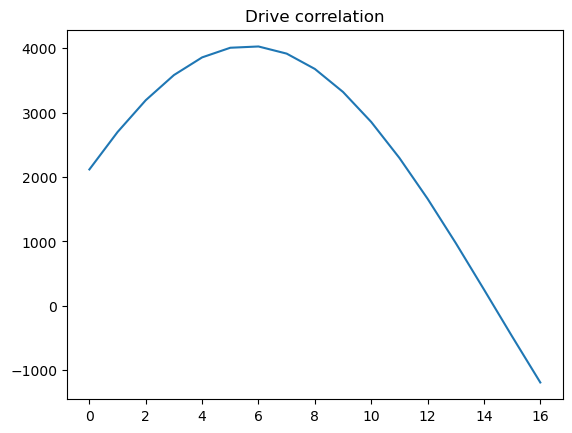


=== File 8 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


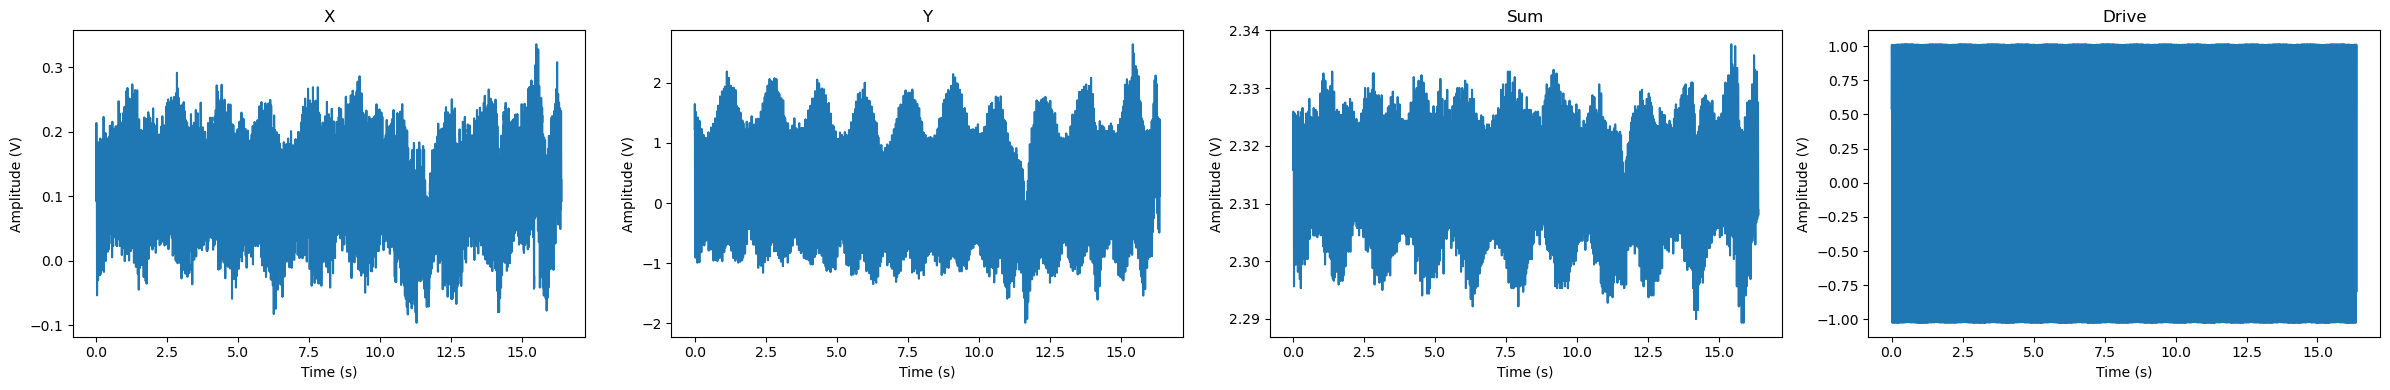

Drive frequency: 28.63 Hz
Peak amplitude: 1.02 V^2/Hz


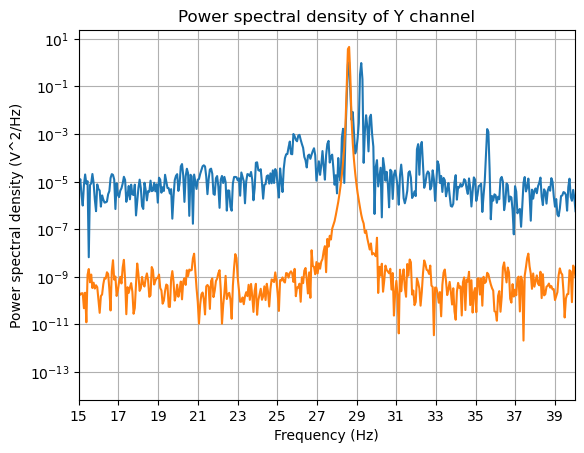

Max correlation: 4.04e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


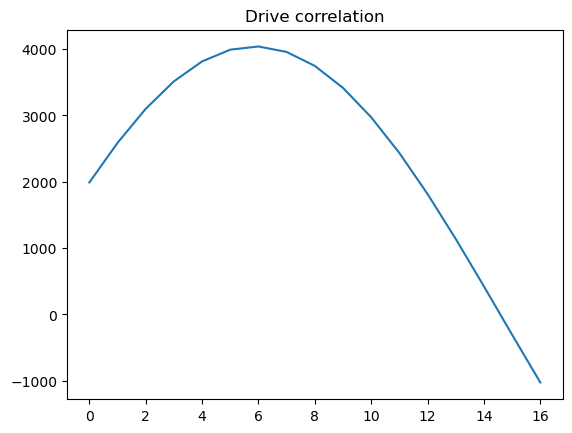


=== File 9 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


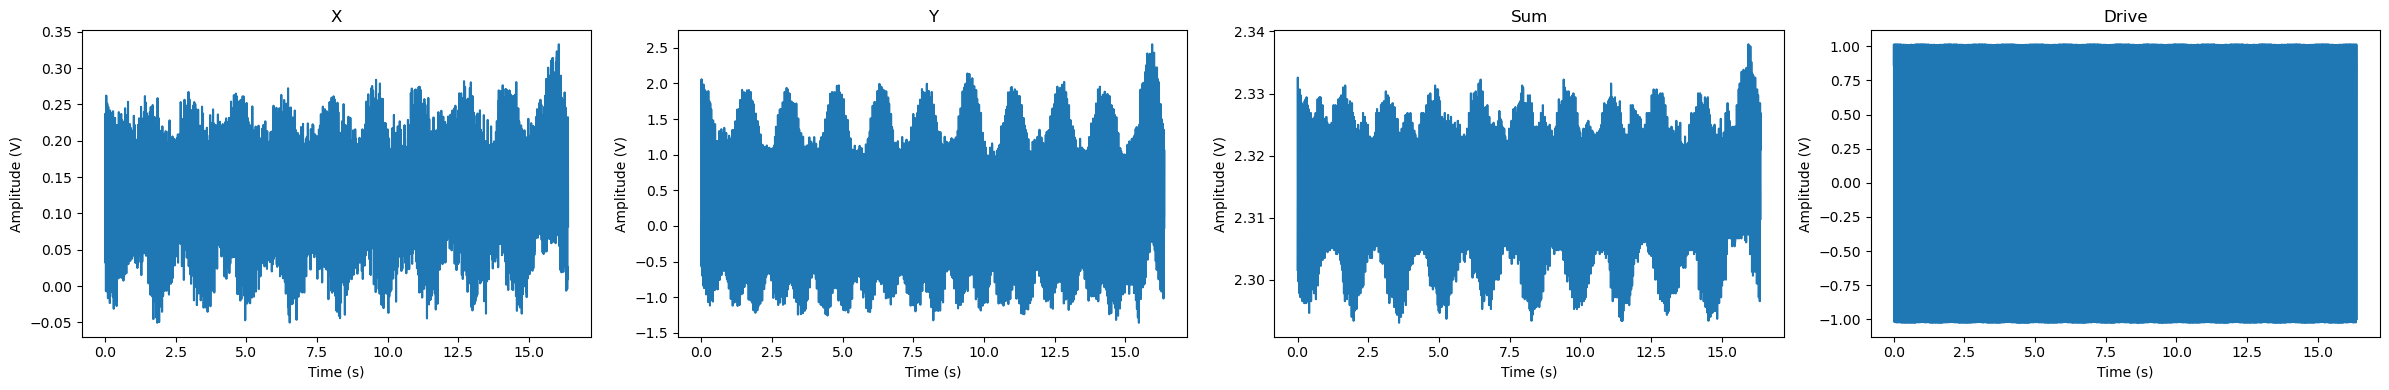

Drive frequency: 28.63 Hz
Peak amplitude: 1.20 V^2/Hz


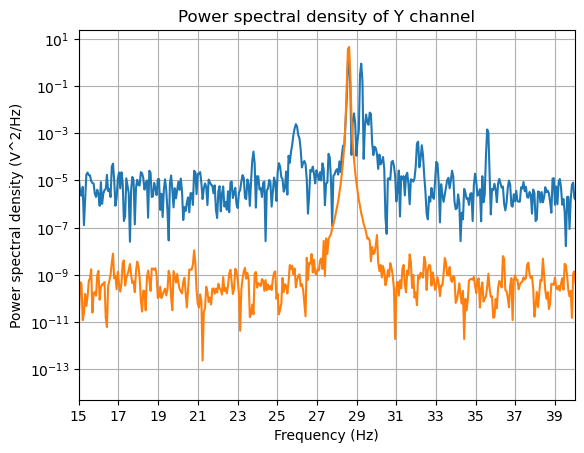

Max correlation: 4.38e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


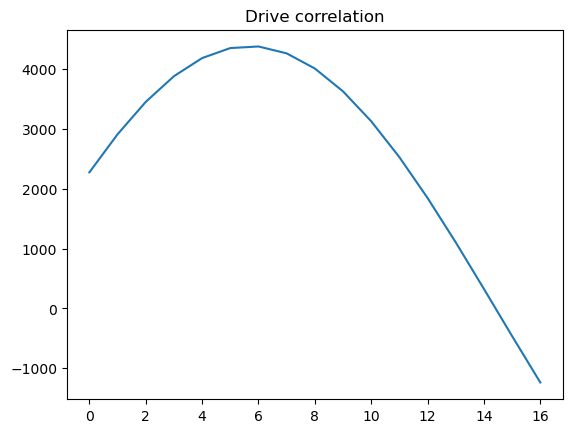


=== File 10 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


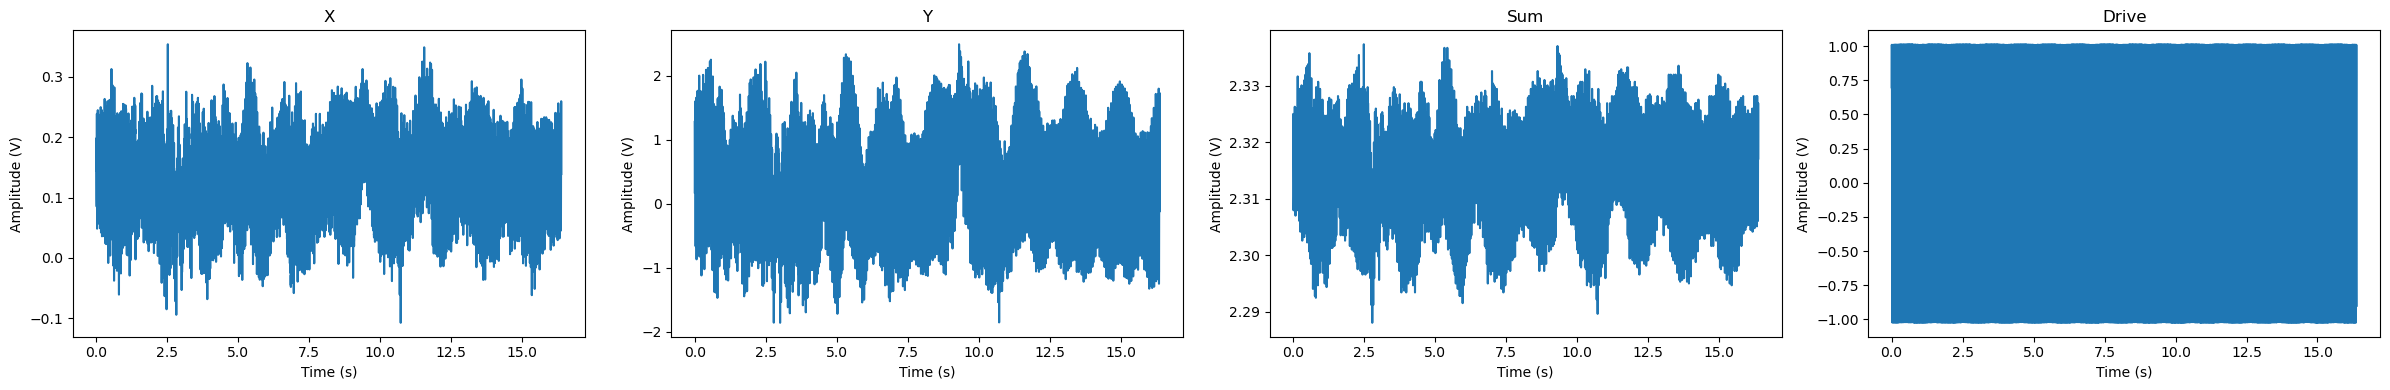

Drive frequency: 28.63 Hz
Peak amplitude: 1.17 V^2/Hz


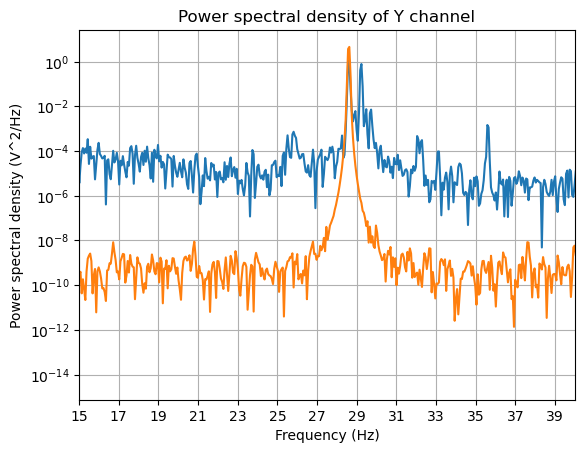

Max correlation: 4.40e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


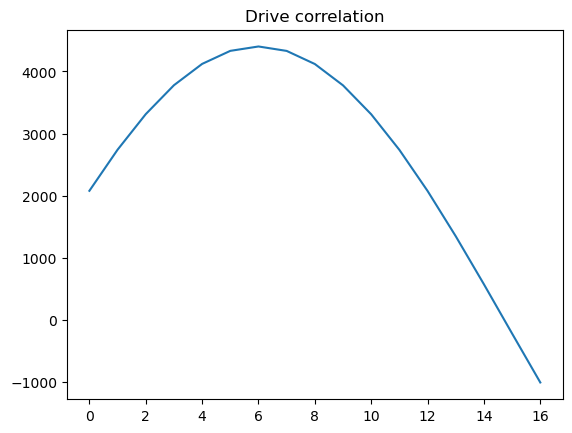


=== File 11 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


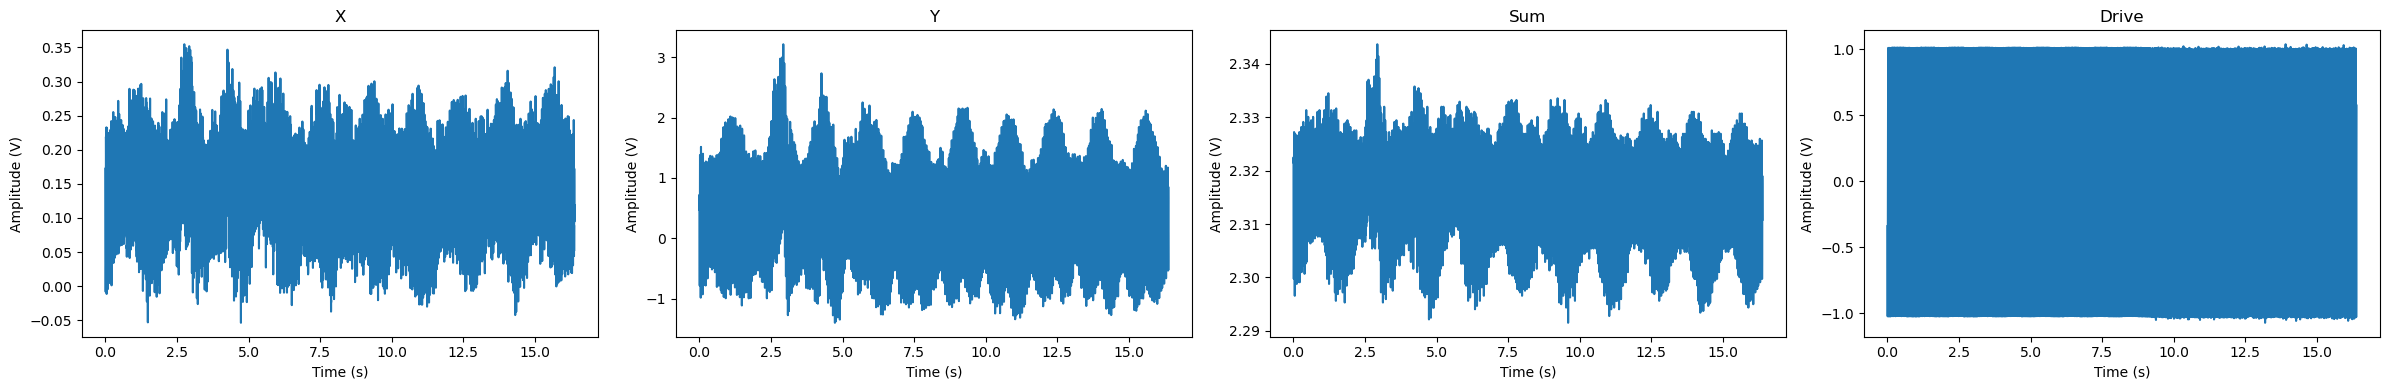

Drive frequency: 28.63 Hz
Peak amplitude: 1.46 V^2/Hz


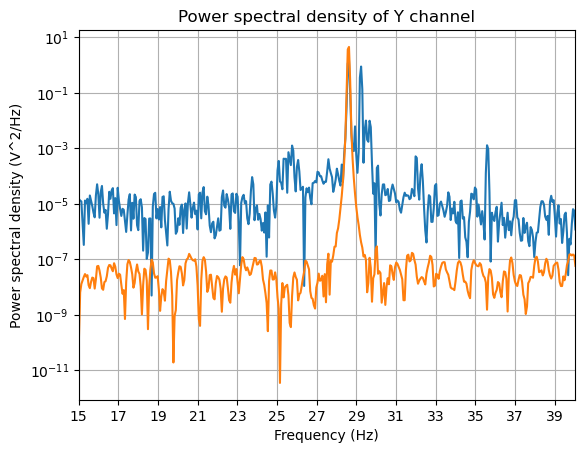

Max correlation: 4.56e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


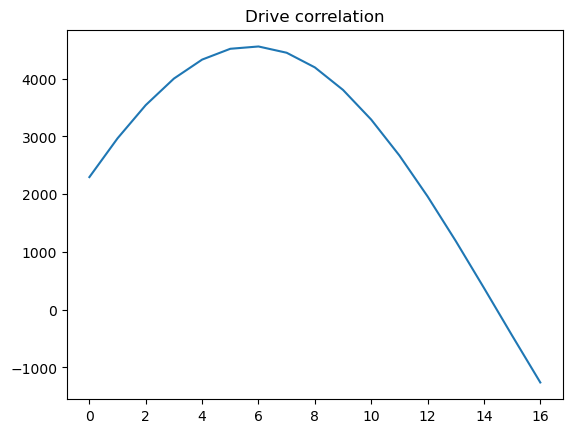


=== File 12 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


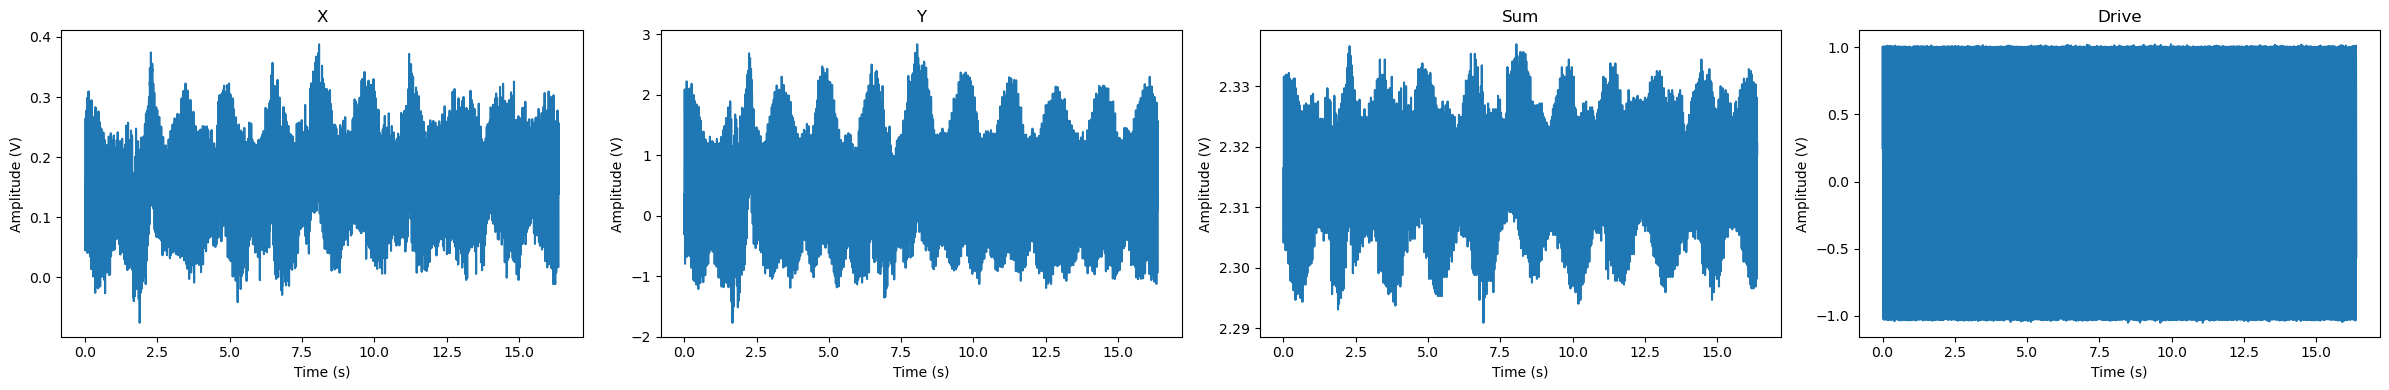

Drive frequency: 28.63 Hz
Peak amplitude: 1.40 V^2/Hz


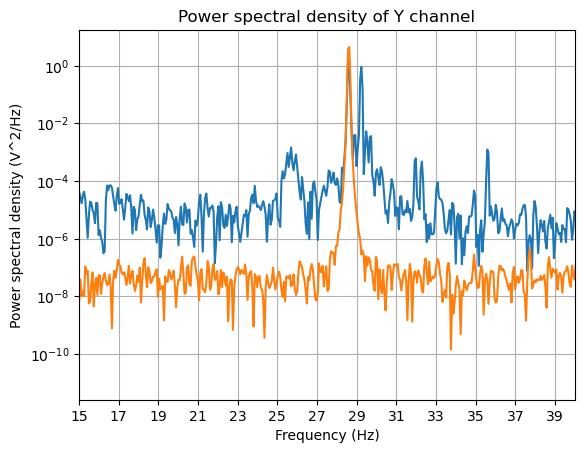

Max correlation: 4.78e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


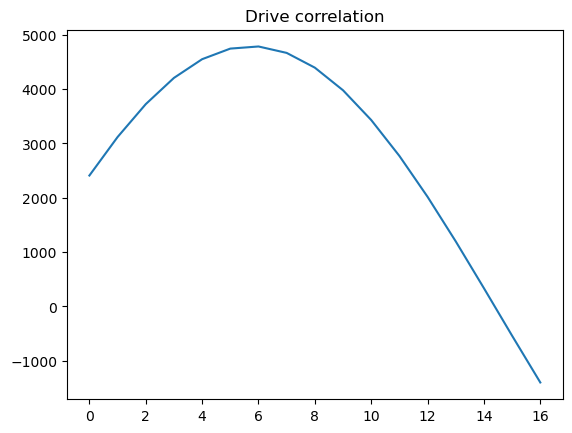


=== File 13 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.
got data:  65536


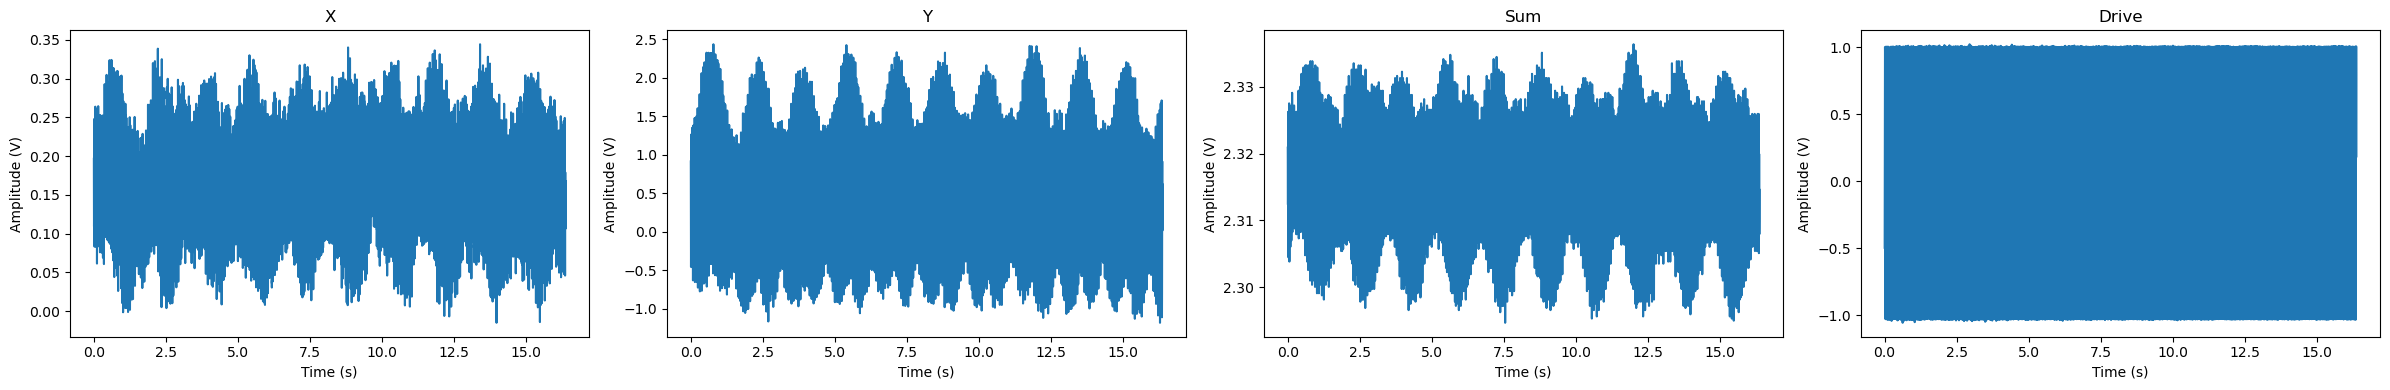

Drive frequency: 28.63 Hz
Peak amplitude: 1.32 V^2/Hz


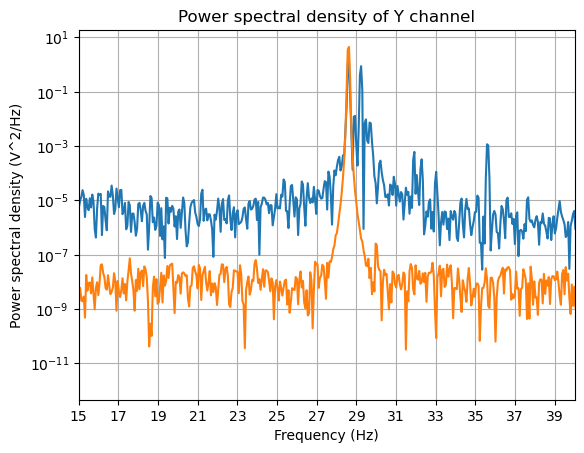

Max correlation: 4.53e+03 V^2/Hz
Peak lag: 0.01 s
Phase shift: 1.13 rad
Phase shift: 64.80 deg


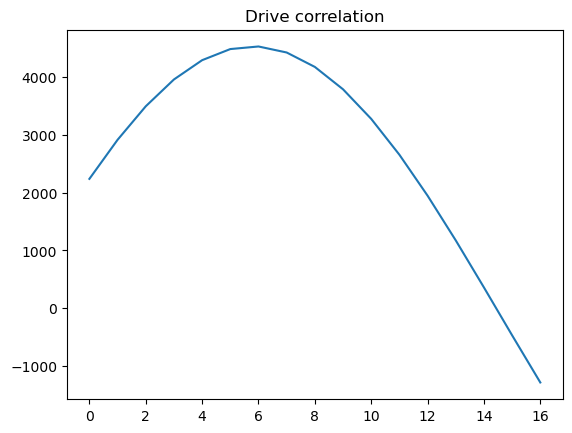


=== File 14 | Phase = filament ===
phase = filament, set_filament = True
turning on filament
turning off filament
Opened a LabJack with Device type: 7, Connection type: 1,
Serial number: 470037304, IP address: 0.0.0.0, Port: 0,
Max bytes per MB: 64
Scans per read:  16384

Stream started with a scan rate of 1000 Hz.


In [ ]:
# adding filament and UV LED to loop
# phase sizes (in # of files)
num_files = 300
baseline_size = 4
filament_size = 100
uv_size = 0

# store amp/freq
max_corr_amp = []
max_psd_amp  = []
max_psd_freq = []
phase_shift_deg_list = []

for file_idx in range(num_files):
    # Determine phase
    if file_idx < baseline_size:
        phase = "baseline"
    elif file_idx < baseline_size + filament_size:
        phase = "filament"
    elif file_idx < baseline_size + filament_size + uv_size:
        phase = "UV"
    else:
        phase = "post-UV"

    print(f"\n=== File {file_idx} | Phase = {phase} ===")

    # Phase actions
    if phase == "filament" and set_filament:
        print(f"phase = {phase}, set_filament = {set_filament}")
        print('turning on filament')
        ppx.set_output(fil_supply, 'on')
        time.sleep(filament_time_on)   # 1.0 s on
        ppx.set_output(fil_supply, 'off')
        print('turning off filament')

    elif phase == "UV" and flash_LED:
        print(f"phase = {phase}, flash_LED = {flash_LED}")
        # trigger one 0.5 s LED burst
        print('flasing LED')
        led_afg.send_manual_trigger(led_channel)
        #time.sleep(led_width + 0.1)
        print('LED flash complete')

    # Pressure reading
    if save_pressure:
        start_pressure = read_pressure(pressure_port)

    # Data acquisition
    lj.open()
    lj.config(sample_rate=sampling_rate,
              num_samps_to_read=num_samples,
              channel_list=channels_to_read)
    data, totSkip = lj.read_analog_in(num_scans=num_traces_per_file)
    lj.close()

    if save_pressure:
        end_pressure = read_pressure(pressure_port)

    if totSkip > 0:
        print(f"Warning: skipped {totSkip} samples")

    # Save
    if save_data:
        ts = datetime.datetime.now().strftime('%H%M%S')
        if save_pressure:
            pressure_data = [start_pressure, end_pressure]
            fname = (f"{output_path}"
                     f"{phase}_" 
                     f"transfer_func_{noise_playback_freq:.3f}Hz_"
                     f"{synth_amplitude:.3f}V_"
                     f"{start_pressure:.2e}bar_{ts}.npz")
        else:
            pressure_data = None
            fname = (f"{output_path}"
                     f"{phase}_"
                     f"transfer_func_{noise_playback_freq:.3f}Hz_"
                     f"{synth_amplitude:.3f}V_{ts}.npz")

        np.savez(fname,
                 data=data,
                 Fs=sampling_rate,
                 noise_playback_freq=noise_playback_freq,
                 synth_amplitude=synth_amplitude,
                 pressure_data=pressure_data)

    # Plot raw time series
    if plot_data:
        t = np.arange(num_samples) / sampling_rate
        plt.figure(figsize=(6*num_channels,4))
        for ch in range(num_channels):
            plt.subplot(1, num_channels, ch+1)
            plt.plot(t, data[0][:,ch])
            plt.xlabel("Time (s)")
            plt.ylabel("Amplitude (V)")
            plt.title(ch_names[ch])
        plt.tight_layout()
        plt.show()

    # PSD on Y channel only
    if plot_PSD:
        ## plot power spectral density
        arr = data[0] # take first trace
        y_channel = ch_names.index('Y')
        drive_channel = ch_names.index('Drive')
        f, Pyy = sp.welch(arr[:,y_channel], fs=sampling_rate, nperseg=num_samples)
        f, Pdd = sp.welch(arr[:,drive_channel], fs=sampling_rate, nperseg=num_samples)

        drive_max_idx = np.argmax(Pdd)
        drive_freq = f[drive_max_idx]
        max_psd_freq.append(drive_freq)
        print(f"Drive frequency: {drive_freq:.2f} Hz")
        peak_amp = Pyy[drive_max_idx]
        max_psd_amp.append(peak_amp)
        print(f"Peak amplitude: {peak_amp:.2f} V^2/Hz")

        plt.figure()
        plt.semilogy(f, Pyy)
        plt.semilogy(f, Pdd)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density (V^2/Hz)")
        plt.title("Power spectral density of Y channel")
        plt.xlim(15, 40)
        plt.grid()
        plt.xticks(np.arange(15, 40, 2))
        plt.show()

    # Lock-in-style correlation
    if plot_drive_correlation:
        correlation_channel = ch_names.index('Y')
        drive_channel  = ch_names.index('Drive')
        corr_val = sp.correlate(
            data[0][:, correlation_channel],
            data[0][:-num_corr_samples, drive_channel],
            mode='valid'
        )
        roi_start, roi_end = 5, 8
        window = corr_val[roi_start:roi_end]
        relative_idx = np.argmax(window)
        peak_idx = roi_start + relative_idx
        max_corr = corr_val[peak_idx]
        max_corr_amp.append(max_corr)
        print(f"Max correlation: {max_corr:.2e} V^2/Hz")

        lag = peak_idx / sampling_rate
        print(f"Peak lag: {lag:.2f} s")
        phase_shift = 2 * np.pi * f0 * lag
        print(f"Phase shift: {phase_shift:.2f} rad")
        phase_shift_deg = np.rad2deg(phase_shift)
        print(f"Phase shift: {phase_shift_deg:.2f} deg")
        phase_shift_deg_list.append(phase_shift_deg)

        # max_corr = np.max(corr_val[roi_start:roi_end])
        # max_corr_amp.append(max_corr)
        # print(f"Max correlation: {max_corr:.2e}")

        plt.figure()
        plt.plot(corr_val)
        plt.title("Drive correlation")
        plt.show()

Max correlation values:  [11626.668404900778, 11433.171620868176, 11573.905915822008, 11384.605865320174, 11412.237197018261, 11362.615301425634, 11158.88084560238, 11426.118064103755, 11418.977052441598, 11361.932195739222, 10387.684910816117, 10008.568046318655, 9926.214949072206, 9535.540755070055, 9250.004998316523, 8957.3971819947, 9034.911824635688, 8756.582698999075, 8400.713128866775, 8329.643993501784, 8161.236736028446, 7899.929417211216, 7701.165501973033, 7346.666039638146, 7088.985415707738, 6696.1341985047475, 6584.159289010894, 6630.929651605135, 6237.405783155954, 5913.362617650817]
Length of max correlation values:  30


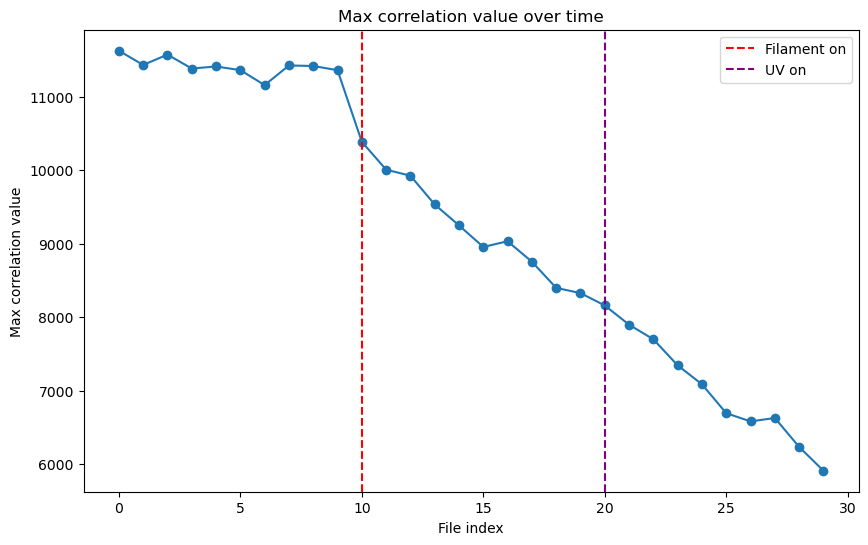

In [71]:
print("Max correlation values: ", max_corr_amp)
print("Length of max correlation values: ", len(max_corr_amp))

filament_start = baseline_size
uv_start = baseline_size + filament_size

plt.figure(figsize=(10,6))
plt.plot(max_corr_amp, 'o-')
plt.xlabel("File index")
plt.ylabel("Max correlation value")
plt.title("Max correlation value over time")
plt.axvline(filament_start, color='r', linestyle='--', label='Filament on')
plt.axvline(uv_start, color='purple', linestyle='--', label='UV on')
plt.legend()
plt.savefig('max_corr_1.5fil_2.png')


Text(0.5, 1.0, 'Max value over time')

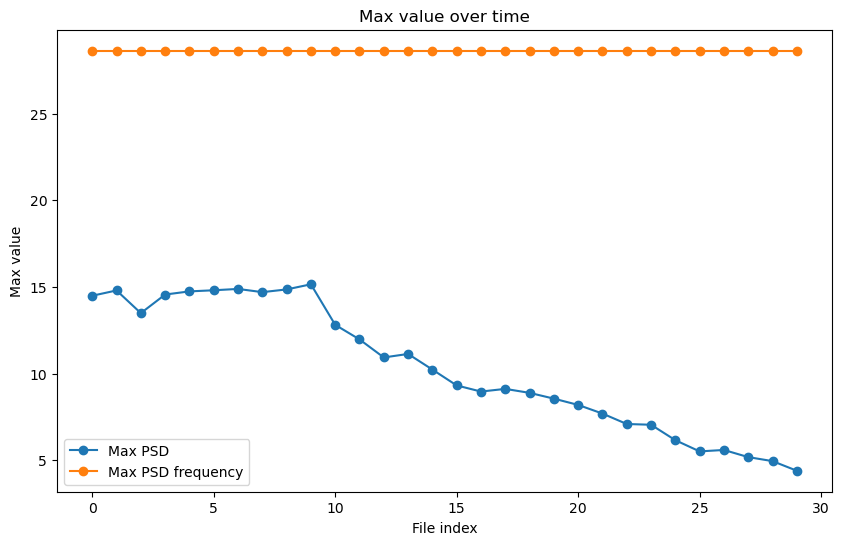

In [63]:
plt.figure(figsize=(10,6))
plt.plot(max_psd_amp, 'o-')
plt.plot(max_psd_freq, 'o-')
plt.legend(['Max PSD', 'Max PSD frequency'])
plt.xlabel("File index")
plt.ylabel("Max value")
plt.title("Max value over time")

In [14]:
print(read_pressure(pressure_port))
lj.close()

5.02e-07


LJMError: LJM library error code 1224 LJME_DEVICE_NOT_OPEN